In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [50]:
df = pd.read_csv(r"C:\Users\nandi\Mrinmoy_python\AI_ML\YuvaIntern\Data\SuperMarket Analysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [51]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (1000, 17)

Missing Values:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Duplicate Rows: 0


In [52]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Shape after preprocessing:", df.shape)

Shape after preprocessing: (1000, 17)


In [53]:
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

df[["Date", "Month", "Day", "DayOfWeek"]].head()

,Date,Month,Day,DayOfWeek
0,2019-01-05,1,5,5
1,2019-03-08,3,8,4
2,2019-03-03,3,3,6
3,2019-01-27,1,27,6
4,2019-02-08,2,8,4


In [54]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Month                      0
Day                        0
DayOfWeek                  0
dtype: int64

In [55]:
X = df.drop(columns=["Sales", "Invoice ID", "Date"], errors="ignore")
y = df["Sales"]

print("Features:")
print(X.columns.tolist())

print("\nTarget: Sales")

Features:
['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating', 'Month', 'Day', 'DayOfWeek']

Target: Sales


In [56]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Unit price', 'Quantity', 'Tax 5%', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

Categorical Features:
['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Time', 'Payment']


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [58]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [59]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Branch', 'City',
                                                   'Customer type', 'Gender',
                                                   'Product line', 'Time',
                                                   'Payment'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, n_estimators=200,
                                       n_jobs=-1, random_state=42))])

In [60]:
model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [61]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[523.1864925  621.11380625 408.472715   135.888445    44.5362225
 622.69594    127.78517019 732.858385   452.0265575  138.54272906]


In [62]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Random Forest Regression Results
--------------------------------
MAE : 0.7723
MSE : 1.7559
RMSE: 1.3251
R²  : 1.0


In [63]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Cross-Validation R² Scores:")
print(cv_scores)

print("\nMean Cross-Validation R²:",
      round(cv_scores.mean(), 4))

Cross-Validation R² Scores:
[0.99997548 0.99988955 0.99995382 0.99996325 0.99995232]

Mean Cross-Validation R²: 0.9999


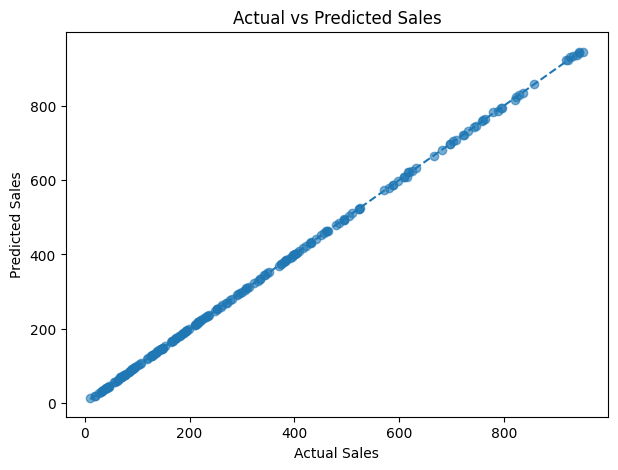

In [64]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

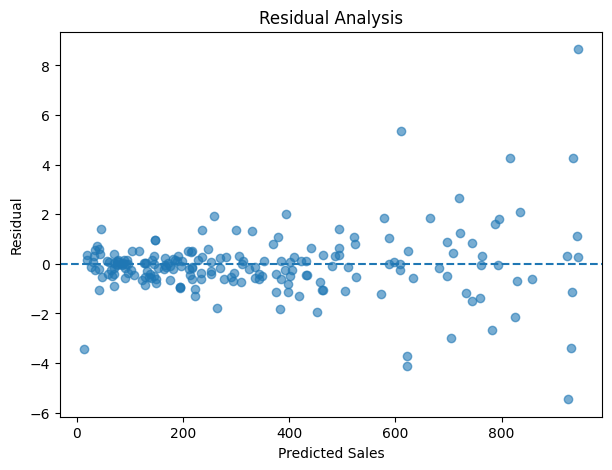

In [65]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

In [66]:
rf_model = model.named_steps["regressor"]
preprocessor_fitted = model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
480,remainder__cogs,0.347977
479,remainder__Tax 5%,0.347130
482,remainder__gross income,0.304796
477,remainder__Unit price,0.000029
483,remainder__Rating,0.000008
485,remainder__Day,0.000007
486,remainder__DayOfWeek,0.000006
474,categorical__Payment_Cash,0.000005
484,remainder__Month,0.000004
14,categorical__Product line_Home and lifestyle,0.000004


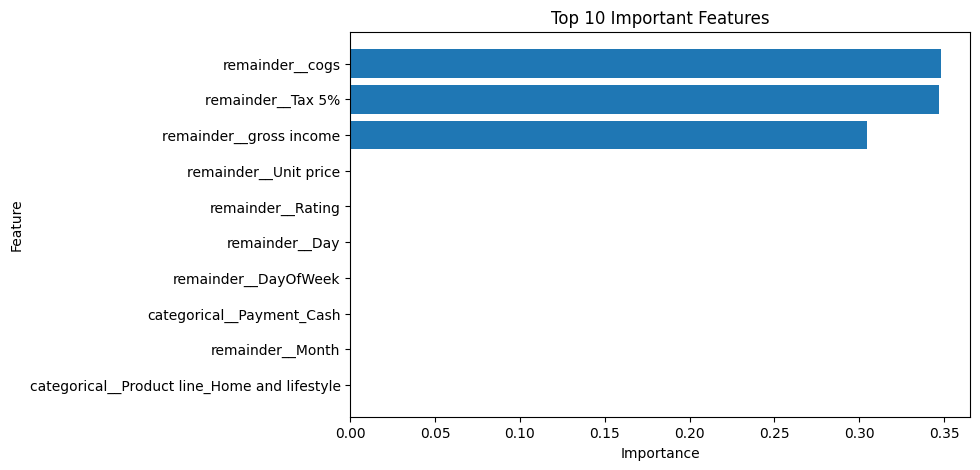

In [67]:
top_features = importance_df.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [68]:
print("FINAL MODEL PERFORMANCE")
print("=======================")

print("Model: Random Forest Regression")
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

print("\n5-Fold Cross-Validation")
print("Mean R²:", round(cv_scores.mean(), 4))
print("Std R² :", round(cv_scores.std(), 4))

FINAL MODEL PERFORMANCE
Model: Random Forest Regression
MAE : 0.7723
MSE : 1.7559
RMSE: 1.3251
R²  : 1.0

5-Fold Cross-Validation
Mean R²: 0.9999
Std R² : 0.0
